# Task #1
Analyzing students' grades through measures of central tendency.

### 📝 Step 1: Import Customized Dataset

The first step is to import a customized dataset in CSV format (here we have 164 rows) with the following four columns:

- 👤 Name
- ➗ Math
- 📖 English
- 🔬 Science

To make the data more realistic, I have added two missing values (students might be absent). This will make us learn how to find and handle missing values.

---
### ⚒️ Tools Utilized

- 🤖 ChatGPT (for customization of dataset)
- 🐍 Python ( for data processing and analysis)  
- 🐼 Pandas library (for importing/loading dataset)
- 📊 Matplotlib library (for data labelling) and Seaborn (for plotting and  visualization)

### 🔑 Key Concepts

- DataFrames, isnull().sum(), fillna(0), mean(),median(), mode(), min(), max(), round(), histplot(), corr(), sort()



In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
students_grades = pd.read_csv("/content/students_grades.csv") # copy file path here
students_grades

,Name,Math,English,Science
0,Ali Khan,86,90.0,88.0
1,Sara Smith,92,44.0,78.0
2,Omar Lee,96,55.0,92.0
3,Lina Patel,91,83.0,100.0
4,Ahmed Brown,92,82.0,47.0
...,...,...,...,...
159,Grace Taylor,94,92.0,81.0
160,Lucas Martinez,85,77.0,90.0
161,Lily Williams,92,88.0,85.0
162,Ethan Davis,86,90.0,88.0


Let's explore our data and find missing values.

In [22]:
missing_values = students_grades.isnull().sum() # null/Nan/missing values are same
missing_values  # This shows we have one missing value in english column and one missing value in science column

,0
Name,0
Math,0
English,1
Science,1


## 🧹 Imputation of Missing Values
Let's impute the missing values.

Generally,

- If too much data is missing in a row or column drop it---> dropna()
- Important dataset with missing values, fill it with --->mean
- Time series data backward fill/forward fill---> (ffill)/(bfill)
- Absentees missing data, fill it with zero -->fillna(0)

Hence, for absent students, we will place zero in respective subjects.


In [23]:
students_grades.fillna(0, inplace=True) # inplace=True will modify our original data frame
missing_values = students_grades.isnull().sum() # cross check if values are filled
missing_values

,0
Name,0
Math,0
English,0
Science,0


## 📊 Calculate Average Score
Now, lets calculate the average/mean score of each student
>💡We will utilise .mean() function to easily compute the average of each student in all subjects.


In [24]:
Average_score = students_grades[["Math", "English", "Science"]].mean(axis=1) # axis=1 means across columns for each row
Average_score                                                                # multiple brackets as we have multiple columns

,0
0,88.000000
1,71.333333
2,81.000000
3,91.333333
4,73.666667
...,...
159,89.000000
160,84.000000
161,88.333333
162,88.000000


### 🎯Round Off Average Scores

To simplify and make the data more readable, let’s round the average scores to one decimal place.

>💡 Using.round(1) function to achieve this


In [25]:
Average_score = Average_score.round(1)
Average_score

,0
0,88.0
1,71.3
2,81.0
3,91.3
4,73.7
...,...
159,89.0
160,84.0
161,88.3
162,88.0


### 📌Add Average Score to Original Dataset

To analyze the scores side by side with the original data, we can add the average score column directly to the dataset.

>💡 This will helps us in comparing each student’s overall performance along with their individual subject scores.

In [26]:
students_grades["Average_score"]= Average_score
students_grades

,Name,Math,English,Science,Average_score
0,Ali Khan,86,90.0,88.0,88.0
1,Sara Smith,92,44.0,78.0,71.3
2,Omar Lee,96,55.0,92.0,81.0
3,Lina Patel,91,83.0,100.0,91.3
4,Ahmed Brown,92,82.0,47.0,73.7
...,...,...,...,...,...
159,Grace Taylor,94,92.0,81.0,89.0
160,Lucas Martinez,85,77.0,90.0,84.0
161,Lily Williams,92,88.0,85.0,88.3
162,Ethan Davis,86,90.0,88.0,88.0


### 🚀Find Maximum Average Score

To check the maximum/highest value in the Average_Score column:

>💡We will Use the .max() function to quickly find the highest score.

In [27]:
Highest_average = students_grades["Average_score"].max()
Highest_average

92.0

Similarly, for lowest average in the dataset, we will use .min() function

In [28]:
Lowest_average = students_grades["Average_score"].min()
Lowest_average

49.3

Likewise, other parameters like mode and median can also be found.

In [29]:
mode_of_average = students_grades["Average_score"].mode().tolist()
mode_of_average

[87.3]

In [30]:
median_of_average = students_grades["Average_score"].median()
median_of_average

84.0

### 📊📈 Charts/maps
Charts/maps are excellent way to quicky analyze our dataset. Generally we use,
- Bar chart  for ---> one on one comparison
-	Highlighted bar---> to find top value
- Grouped bar --->similar characteristics comparison
-	Heatmap ---> Spotting patterns
-	Histogram ---> to see distribution

Since we are doing analysis of students' grades, let's dig into distribution of students' average scores.

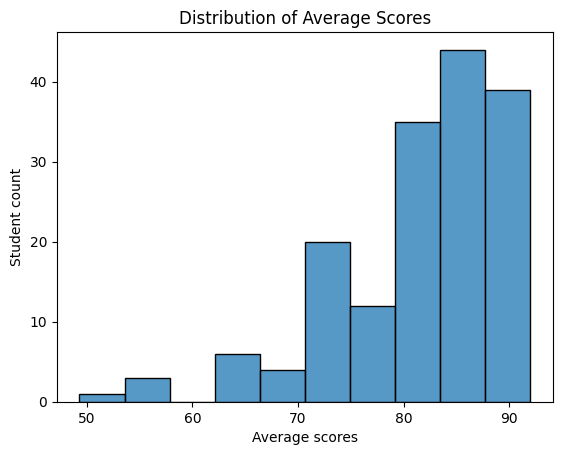

In [31]:
sns.histplot(students_grades["Average_score"], bins=10)
plt.xlabel("Average scores")
plt.ylabel("Student count")
plt.title("Distribution of Average Scores")

plt.show()

# This shows that most students' average lie in the score bracket of 80 to 90.

### 🎯Correlation

Correlation measures how strongly our variables are related to each other.
- +1 -->positive relationship
-  0 -->  No relationship
- -1 -->negative relationship

👉 In our case:
How Math scores relate to Science scores, how English scores relate to Math, etc.

In [32]:
students_grades[['Math','English','Science']].corr().round(2)  # Here, for our data english and math and english and science have no relationship while math and science are negatively correlated.

,Math,English,Science
Math,1.00,0.13,-0.05
English,0.13,1.00,0.03
Science,-0.05,0.03,1.00


### 🔢 Sorting

While the `.max()` function helps identify the single highest value in a dataset, sorting provides a more comprehensive view of the data.

By arranging values in **ascending** or **descending** order (depending on the requirement), we can:
- Easily find the maximum value  
- Identify values close to the maximum  
- Observe the overall trend and distribution of the data  

In [33]:
Average_high_to_low = students_grades["Average_score"].sort_values(ascending=False)
Average_high_to_low

,Average_score
122,92.0
139,92.0
58,92.0
41,92.0
74,91.7
...,...
28,65.0
6,54.7
26,54.7
87,54.7


### 🏆Find Student with Highest Average

To identify the student with the highest average, we can locate the name in the dataset corresponding to the highest average score.

>💡We will use .loc[] to locate the student/students name corresponding to the highest average easily

tolist() is used to cater the problem if there are multiple names having same values, so it shows us a list of all those names.

In [34]:
student_with_highest_average = students_grades.loc[students_grades["Average_score"] == Highest_average, "Name"].tolist() # "toist()" is used to cater the problem if there are multiple names with max_value

word = "Student" if len(student_with_highest_average) == 1 else "Students"

print(f"{word} with highest average score: {','.join(student_with_highest_average)}")

Students with highest average score: Lina Perez,Leo Garcia,James Wright,Amelia Robinson


### 📝Summary:

The first assignment helps us get hands-on experience with the basic yet essential concepts like loading a dataset, calculating measures of central tendency (mean, median, mode, min, max), finding missing values, imputation of missing values, rounding values, analyzing frequency distribution through histogram, correlation in our dataset, sorting for better visualization and locating corresponding values in the dataset. All these techniques are essential for analyzing and working with data effectively which are core concepts of data analysis and manipulation.